In [ ]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 1

import numpy as np
from astropy.io import ascii
import os
import matplotlib.pyplot as plt
from astropy.utils.data import download_file
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.nddata import Cutout2D
from astropy import units as u
from photutils.aperture import aperture_photometry
from photutils.aperture import CircularAperture
from photutils.aperture import CircularAnnulus
from astropy.stats import sigma_clipped_stats

from photutils.psf import fit_fwhm
os.chdir("/Users/dapur")

plate_fits = fits.open('C:/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA/cutouts/00264_a01988m0s0.fits')
plate_fits.info()
image_data = plate_fits[0].data

Filename: C:/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA/cutouts/00264_a01988m0s0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      30   (835, 835)   int16   


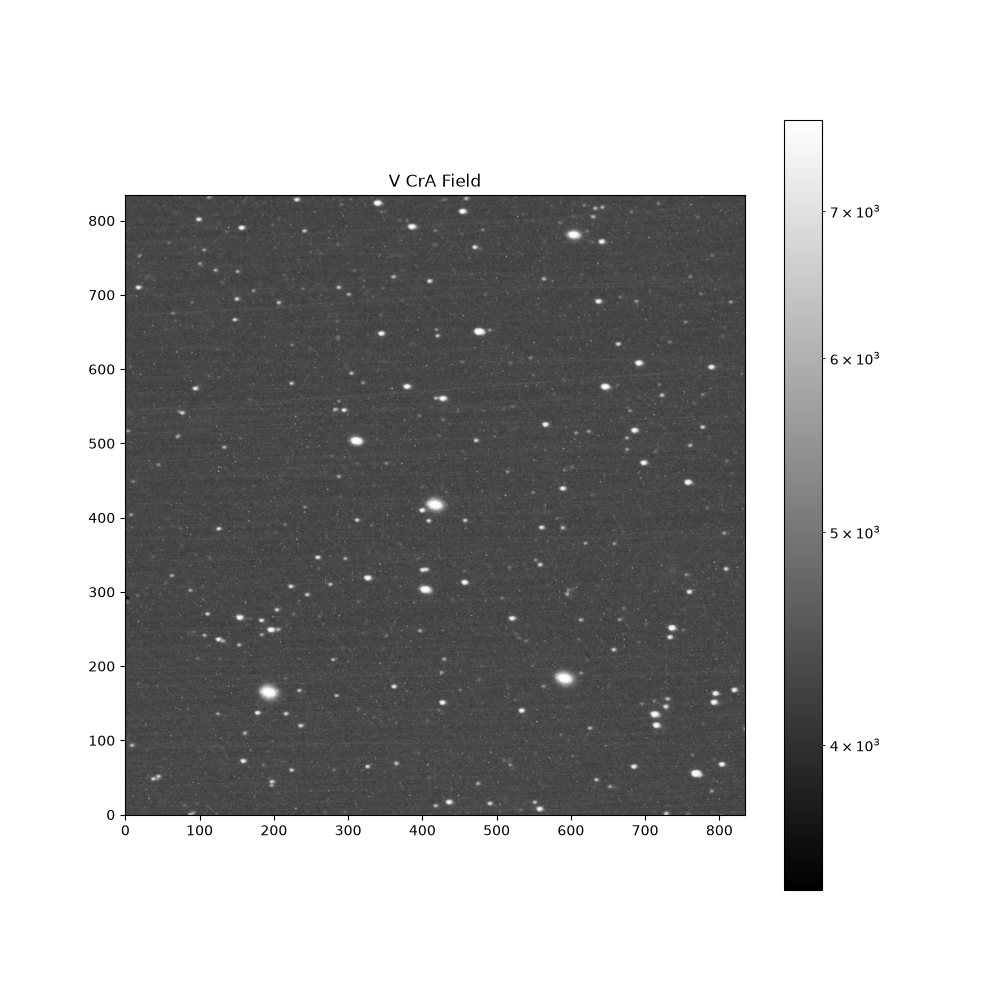

In [ ]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 2

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(image_data, origin='lower', cmap='gray', norm=LogNorm())
ax.set_title('V CrA Field')

def format_coord(x, y):
    col = int(x + 0.5)
    row = int(y + 0.5)
    if 0 <= row < image_data.shape[0] and 0 <= col < image_data.shape[1]:
        value = image_data[row, col]
        return f'x={col}, y={row}, value={value:.1f}'
    return f'x={col}, y={row}'

ax.format_coord = format_coord
plt.colorbar(im, ax=ax)
plt.show()

APASS returned 475 raw matches within 892.7 arcsec of field center
260 APASS stars kept after trimming edge sources (margin=42px)

id  x         y         RA          Dec         Bmag
0   281.7     60.8      281.95357   -38.30143   15.71
1   43.1      49.6      282.07524   -38.30579   14.29
2   44.9      103.9     282.07425   -38.28404   17.53
3   198.2     43.3      281.99614   -38.30841   14.29
4   187.0     66.8      282.00184   -38.29900   15.95
5   159.8     72.5      282.01572   -38.29669   13.97
6   256.2     95.2      281.96656   -38.28767   16.44
7   226.1     59.4      281.98192   -38.30196   14.63
8   237.3     118.6     281.97617   -38.27828   14.44
9   217.0     135.2     281.98654   -38.27163   14.66
10  193.5     84.4      281.99855   -38.29196   16.63
11  192.6     164.7     281.99892   -38.25985   10.25
12  178.9     123.4     282.00595   -38.27634   17.34
13  179.0     137.2     282.00590   -38.27084   14.04
14  161.8     109.6     282.01469   -38.28186   14.84
15  12

C:\Users\dapur\AppData\Local\Temp\ipykernel_25644\783741409.py:260: RuntimeWarning: invalid value encountered in log10
  instrumental_mag = -2.5 * np.log10(final_sum2)


Dropped 4 star(s) from the fit: background-subtracted flux was <= 0 (negative/zero counts -> undefined magnitude)
Mean background noise (sigma): 80.07 counts
5-sigma detection threshold flux: 28385.5 counts
Estimated plate limit (5-sigma): B ~ 15.39 mag


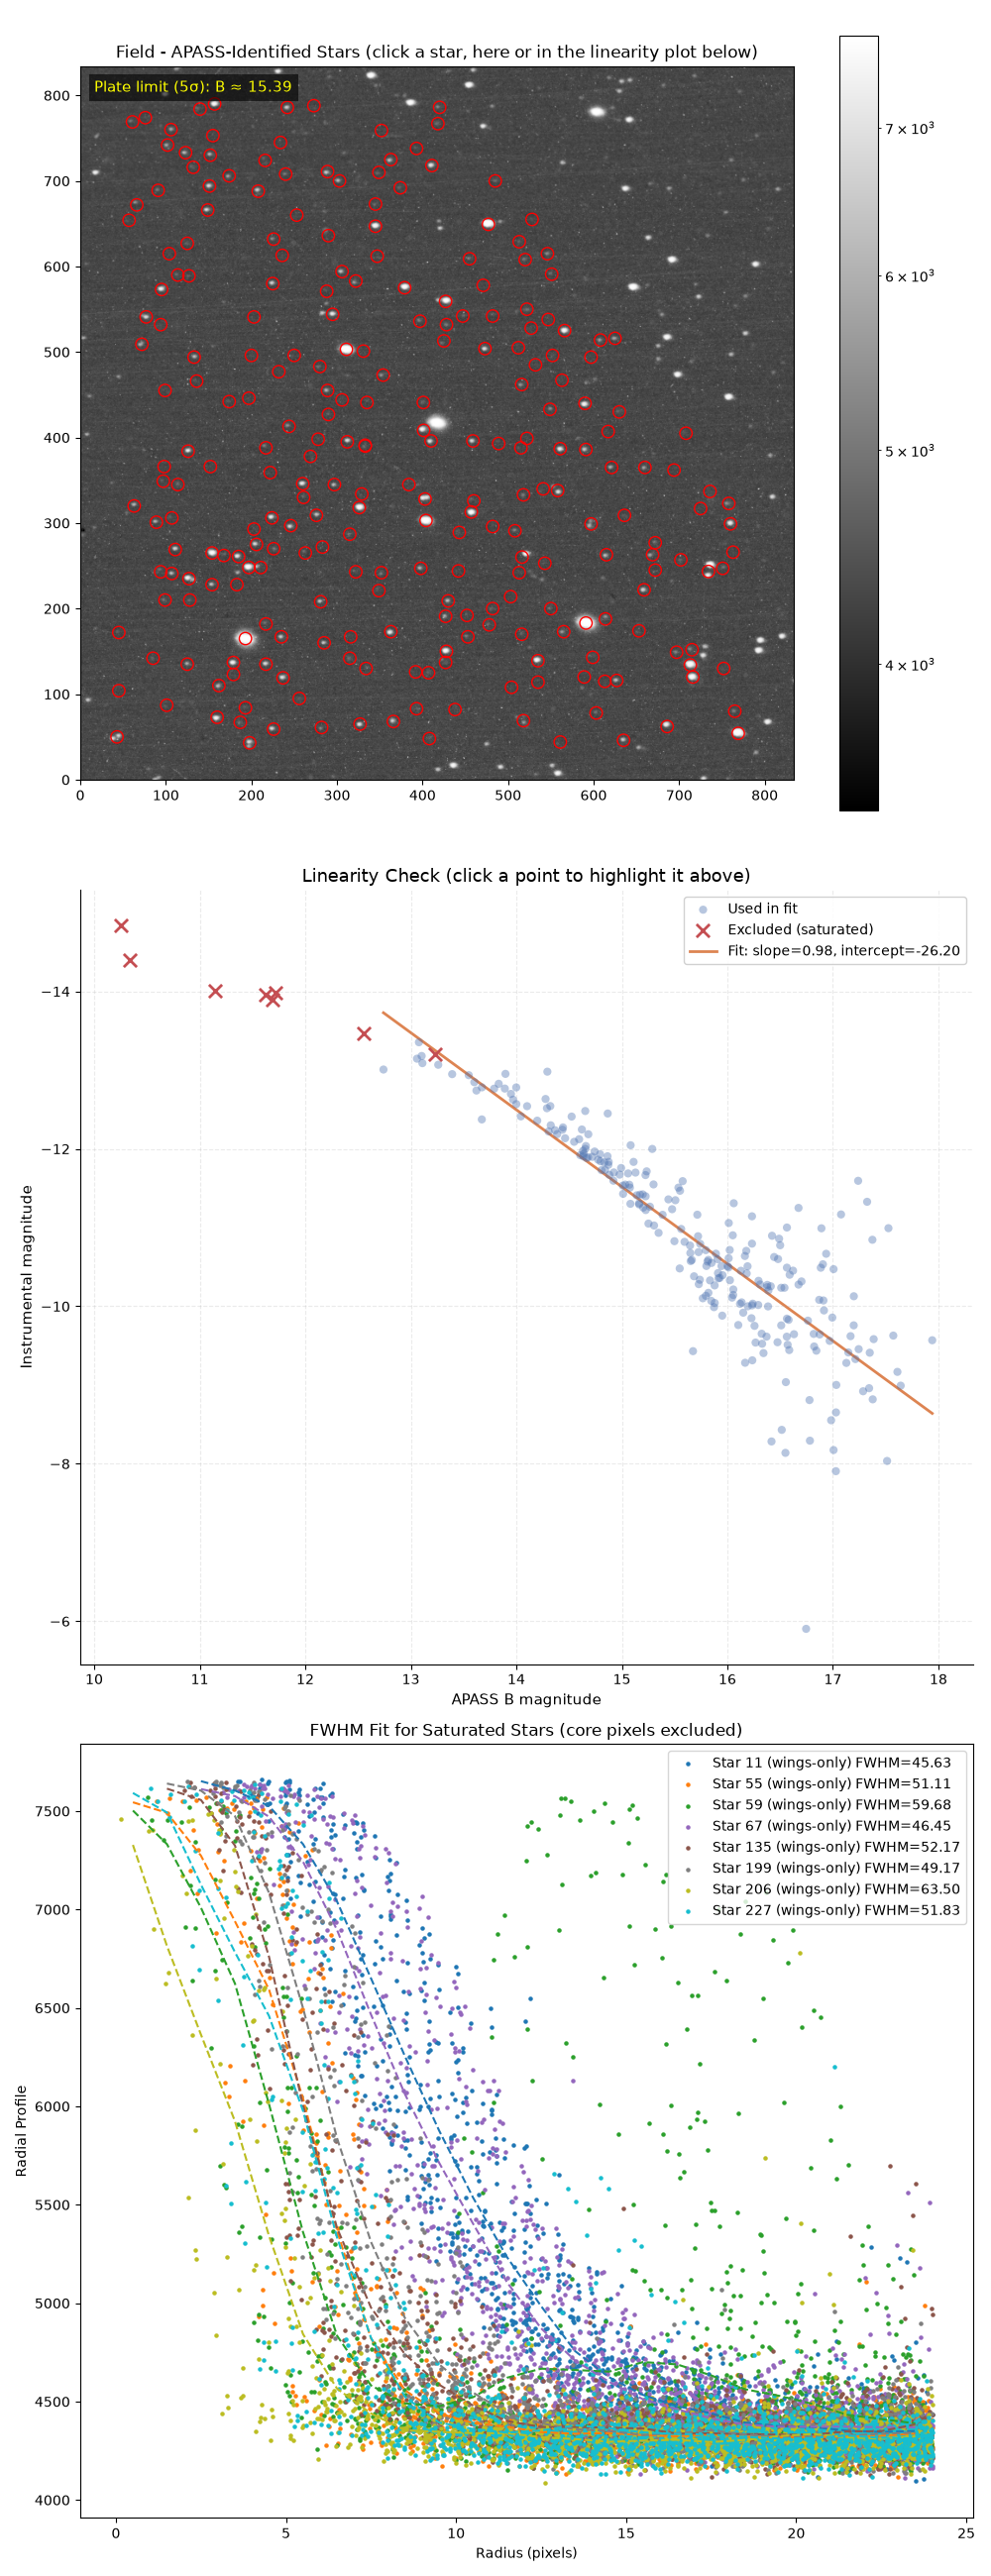


Star 0: residual = -0.345 mag
Star 1: residual = -0.771 mag
Star 2: residual = -1.946 mag
Star 3: residual = -0.303 mag
Star 4: residual = 0.189 mag
Star 5: residual = -0.098 mag
Star 6: residual = -0.520 mag
Star 7: residual = -0.097 mag
Star 8: residual = -0.174 mag
Star 9: residual = -0.184 mag
Star 10: residual = 0.276 mag
Star 11: residual = 1.327 mag (excluded from fit -- saturated)
Star 12: residual = 0.265 mag
Star 13: residual = 0.042 mag
Star 14: residual = -0.059 mag
Star 15: residual = -0.426 mag
Star 16: residual = -1.013 mag
Star 17: residual = -0.485 mag
Star 18: residual = -0.195 mag
Star 19: residual = -0.059 mag
Star 20: residual = -0.083 mag
Star 21: residual = -0.283 mag
Star 22: residual = -0.063 mag
Star 23: residual = 0.077 mag
Star 24: residual = 0.082 mag
Star 25: residual = 0.206 mag
Star 26: residual = 0.066 mag
Star 27: residual = -0.307 mag
Star 28: residual = -0.800 mag
Star 29: residual = -0.426 mag
Star 30: residual = -1.681 mag
Star 31: residual = -0.8

C:\Users\dapur\AppData\Local\Temp\ipykernel_25644\783741409.py:499: RuntimeWarning: invalid value encountered in log10
  delta_mag_flux = -2.5 * np.log10(final_sum2[i] / final_sum2[ref])


In [ ]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 3

import urllib.request
import urllib.parse
import numpy as np
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from photutils.centroids import centroid_sources, centroid_com
from photutils.profiles import RadialProfile

default_r = 40
annulus_width = 5
min_aperture_r = 8      # never shrink an aperture below this, no matter how crowded
safety_buffer = 2       # pixel gap kept between two neighboring apertures
edge_margin = default_r + safety_buffer  # keep identified stars this far from the image edge

wcs = WCS(plate_fits[0].header)
ny, nx = image_data.shape

# Compute the field center and a search radius that covers the full image, so the
# APASS cone search catches every corner of the frame.
center_ra, center_dec = wcs.all_pix2world(nx / 2.0, ny / 2.0, 0)
corner_x = [0, nx - 1, 0, nx - 1]
corner_y = [0, 0, ny - 1, ny - 1]
corner_ra, corner_dec = wcs.all_pix2world(corner_x, corner_y, 0)

center_coord = SkyCoord(ra=float(center_ra) * u.deg, dec=float(center_dec) * u.deg)
corner_coords = SkyCoord(ra=corner_ra * u.deg, dec=corner_dec * u.deg)
field_radius_arcsec = center_coord.separation(corner_coords).max().to(u.arcsec).value * 1.05  # 5% padding

# Query APASS DR9 (via Vizier ASU-TSV) for every star in the field, not just one target.
# This replaces manually clicking star positions in the image.

def query_apass_field(ra, dec, radius_arcsec, max_rows=500):
    params = {
        '-source': 'II/336/apass9',
        '-c': f'{ra} {dec}',
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = 'https://vizier.cds.unistra.fr/viz-bin/asu-tsv?' + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as response:
        return response.read().decode('utf-8')

def parse_apass_field(raw_text):
    rows = []
    for line in raw_text.splitlines():
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-') or line.startswith('RAJ2000'):
            continue
        parts = line.split('\t')
        if len(parts) < 3:
            continue
        try:
            ra_val = float(parts[0])
            dec_val = float(parts[1])
            bmag_val = float(parts[2]) if parts[2].strip() else np.nan
        except ValueError:
            continue
        rows.append((ra_val, dec_val, bmag_val))
    return rows

raw_field = query_apass_field(float(center_ra), float(center_dec), field_radius_arcsec)
apass_rows = parse_apass_field(raw_field)
print(f"APASS returned {len(apass_rows)} raw matches within {field_radius_arcsec:.1f} arcsec of field center")

# Keep only sources with a measured Bmag, since the rest of this notebook needs it,
# and project every RA/Dec onto this image's pixel grid.
apass_rows = [r for r in apass_rows if not np.isnan(r[2])]
ra_arr = np.array([r[0] for r in apass_rows])
dec_arr = np.array([r[1] for r in apass_rows])
bmag_arr = np.array([r[2] for r in apass_rows])

if len(apass_rows) == 0:
    raise RuntimeError("No APASS sources with a Bmag were found in this field.")

x_arr, y_arr = wcs.all_world2pix(ra_arr, dec_arr, 0)

# Drop anything that lands off the image, or too close to the edge for a full aperture.
in_bounds = (x_arr >= edge_margin) & (x_arr <= nx - 1 - edge_margin) & \
            (y_arr >= edge_margin) & (y_arr <= ny - 1 - edge_margin)

positions = list(zip(x_arr[in_bounds].tolist(), y_arr[in_bounds].tolist()))
apass_B_mag = bmag_arr[in_bounds]
star_ra = ra_arr[in_bounds]
star_dec = dec_arr[in_bounds]
n_stars = len(positions)

print(f"{n_stars} APASS stars kept after trimming edge sources (margin={edge_margin}px)")
print()
print(f"{'id':<4}{'x':<10}{'y':<10}{'RA':<12}{'Dec':<12}{'Bmag'}")
for i in range(n_stars):
    print(f"{i:<4}{positions[i][0]:<10.1f}{positions[i][1]:<10.1f}{star_ra[i]:<12.5f}{star_dec[i]:<12.5f}{apass_B_mag[i]:.2f}")
print()

# Query Gaia DR3 (via Vizier ASU-TSV) for parallax across the same field, then
# cross-match each APASS star to its nearest Gaia source. Parallax gives distance,
# and distance + apparent Bmag gives absolute magnitude -- the "intrinsic brightness"
# each star would have at 10pc, independent of how far away it actually is.

def query_gaia_field(ra, dec, radius_arcsec, max_rows=1000):
    params = {
        '-source': 'I/355/gaiadr3',
        '-c': f'{ra} {dec}',
        '-c.rs': radius_arcsec,
        '-out': 'RA_ICRS,DE_ICRS,Plx,e_Plx',
        '-out.max': max_rows,
    }
    url = 'https://vizier.cds.unistra.fr/viz-bin/asu-tsv?' + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as response:
        return response.read().decode('utf-8')

def parse_gaia_field(raw_text):
    rows = []
    for line in raw_text.splitlines():
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-') or line.startswith('RA_ICRS'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra_val = float(parts[0])
            dec_val = float(parts[1])
            plx_val = float(parts[2]) if parts[2].strip() else np.nan
            eplx_val = float(parts[3]) if parts[3].strip() else np.nan
        except ValueError:
            continue
        rows.append((ra_val, dec_val, plx_val, eplx_val))
    return rows

raw_gaia = query_gaia_field(float(center_ra), float(center_dec), field_radius_arcsec)
gaia_rows = parse_gaia_field(raw_gaia)
print(f"Gaia DR3 returned {len(gaia_rows)} sources within {field_radius_arcsec:.1f} arcsec of field center")

match_radius_arcsec = 2.0  # Gaia astrometry is much tighter than APASS; keeps matches unambiguous
min_parallax_snr = 3       # standard cut -- below this, simple 1/parallax distance is unreliable

distance_pc = np.full(n_stars, np.nan)
abs_mag_B = np.full(n_stars, np.nan)

if len(gaia_rows) > 0:
    gaia_ra = np.array([r[0] for r in gaia_rows])
    gaia_dec = np.array([r[1] for r in gaia_rows])
    gaia_plx = np.array([r[2] for r in gaia_rows])
    gaia_eplx = np.array([r[3] for r in gaia_rows])

    star_coords = SkyCoord(ra=star_ra * u.deg, dec=star_dec * u.deg)
    gaia_coords = SkyCoord(ra=gaia_ra * u.deg, dec=gaia_dec * u.deg)
    match_idx, match_sep, _ = star_coords.match_to_catalog_sky(gaia_coords)

    for i in range(n_stars):
        j = match_idx[i]
        sep_arcsec = match_sep[i].arcsec
        plx = gaia_plx[j]
        eplx = gaia_eplx[j]

        if sep_arcsec > match_radius_arcsec:
            print(f"Star {i}: no Gaia match within {match_radius_arcsec}\" (nearest was {sep_arcsec:.2f}\")")
            continue
        if np.isnan(plx) or plx <= 0:
            print(f"Star {i}: Gaia match found but parallax is missing or non-positive, skipping distance")
            continue
        if np.isnan(eplx) or (plx / eplx) < min_parallax_snr:
            print(f"Star {i}: Gaia parallax S/N below {min_parallax_snr}, skipping distance")
            continue

        d_pc = 1000.0 / plx  # parallax in mas -> distance in pc
        distance_pc[i] = d_pc
        abs_mag_B[i] = apass_B_mag[i] - 5 * np.log10(d_pc) + 5  # distance modulus, no extinction correction
        print(f"Star {i}: Gaia match at {sep_arcsec:.2f}\", distance={d_pc:.1f} pc, M_B={abs_mag_B[i]:.2f}")
else:
    print("No Gaia sources returned for this field -- distance/absolute magnitude will be unavailable for all stars")
print()

# Refine each star's pixel position via centroiding, instead of trusting the
# WCS-projected coordinates exactly. Even a few pixels of miscentering biases
# the flux captured in a fixed-radius aperture.

xs_init = np.array([p[0] for p in positions], dtype=float)
ys_init = np.array([p[1] for p in positions], dtype=float)
centroid_box = 21  # pixels; should comfortably contain the star's peak but not a neighbor

xs_refined, ys_refined = centroid_sources(image_data, xs_init, ys_init,
                                           box_size=centroid_box, centroid_func=centroid_com)

print("Centroid refinement (original -> refined):")
for i in range(n_stars):
    dx = xs_refined[i] - xs_init[i]
    dy = ys_refined[i] - ys_init[i]
    flag = "  <-- shifted >3px, check this one" if np.hypot(dx, dy) > 3 else ""
    print(f"  Star {i}: ({xs_init[i]:.1f}, {ys_init[i]:.1f}) -> ({xs_refined[i]:.2f}, {ys_refined[i]:.2f})  shift=({dx:+.2f}, {dy:+.2f}){flag}")
print()

positions = list(zip(xs_refined.tolist(), ys_refined.tolist()))
positions_arr = np.array(positions, dtype=float)

# Adaptive aperture sizing: shrink a star's aperture only if a neighbor is close
# enough that default r=40 apertures would physically overlap and contaminate
# each other's flux. Uncrowded stars keep the full r=40 aperture.

min_sep = np.full(n_stars, np.inf)
for i in range(n_stars):
    for j in range(n_stars):
        if i == j:
            continue
        d = np.hypot(positions_arr[i,0]-positions_arr[j,0], positions_arr[i,1]-positions_arr[j,1])
        min_sep[i] = min(min_sep[i], d)

aper_radii = np.array([min(default_r, sep/2 - safety_buffer) for sep in min_sep])
aper_radii = np.clip(aper_radii, min_aperture_r, default_r)

for i in range(n_stars):
    if min_sep[i] < 2 * default_r:
        note = f" -- shrinking aperture {default_r}px -> {aper_radii[i]:.1f}px to avoid overlap" if aper_radii[i] < default_r else ""
        print(f"Proximity warning: Star {i} nearest neighbor is {min_sep[i]:.1f}px away{note}")
print()

apertures = [CircularAperture(positions[i], r=aper_radii[i]) for i in range(n_stars)]
annuli = [CircularAnnulus(positions[i], r_in=aper_radii[i], r_out=aper_radii[i]+annulus_width) for i in range(n_stars)]

# Full-image mask marking every pixel that falls inside ANY star's aperture. Used to
# strip neighboring stars' light out of each star's local background annulus, even
# if the annuli themselves happen to reach into a neighbor's territory.
combined_star_mask = np.zeros(image_data.shape, dtype=bool)
for ap in apertures:
    ap_image = ap.to_mask(method='center').to_image(image_data.shape)
    if ap_image is not None:
        combined_star_mask |= (ap_image > 0)

aperture_sum_0 = np.zeros(n_stars)
final_sum2 = np.zeros(n_stars)
bkg_std_values = np.zeros(n_stars)

for i in range(n_stars):  # Background subtraction
    t = aperture_photometry(image_data, apertures[i])
    aperture_sum_0[i] = t['aperture_sum'][0]

    ann_mask = annuli[i].to_mask(method='center')
    ann_full = ann_mask.to_image(image_data.shape)
    footprint_full = ann_full > 0
    clean_footprint_full = footprint_full & (~combined_star_mask)  # exclude neighbor stars

    ann_data_1d = image_data[clean_footprint_full]
    _, median_sigclip, std_sigclip = sigma_clipped_stats(ann_data_1d)
    bkg_mean2 = median_sigclip
    bkg_sum2 = bkg_mean2 * apertures[i].area
    final_sum2[i] = aperture_sum_0[i] - bkg_sum2
    bkg_std_values[i] = std_sigclip

print(f"{'id':<4}{'x':<8}{'y':<8}{'aper_r':<10}{'aperture_sum_0':<18}{'residual_sum'}")
for i in range(n_stars):
    print(f"{i:<4}{positions[i][0]:<8.1f}{positions[i][1]:<8.1f}{aper_radii[i]:<10.1f}{aperture_sum_0[i]:<18.1f}{final_sum2[i]:.1f}")
print()

instrumental_mag = -2.5 * np.log10(final_sum2)

# Saturation check for each star (using its own, possibly shrunk, aperture);
# FWHM only computed for saturated stars

edge_radii = np.arange(25)

is_saturated = np.zeros(n_stars, dtype=bool)
fwhm_values = np.full(n_stars, np.nan)
fwhm_profiles = {}

print(f"Overall image max value: {image_data.max()}")
print(f"Overall image min value: {image_data.min()}")
print()

for i, (x, y) in enumerate(positions):
    aperture_mask = apertures[i].to_mask(method='center')
    aperture_data = aperture_mask.multiply(image_data)
    star_pixels = aperture_data[aperture_mask.data > 0]

    max_val = star_pixels.max()
    near_max_count = np.sum(star_pixels >= max_val * 0.995)
    saturated = near_max_count > 5
    is_saturated[i] = saturated

    print(f"Star {i} at ({x:.1f}, {y:.1f}):")
    print(f"  Max pixel value: {max_val}")
    print(f"  Number of pixels within 0.5% of max: {near_max_count}")
    print(f"  Saturated: {saturated}")

    if saturated:
        xycen = (x, y)
        sat_threshold = max_val * 0.995
        sat_mask = image_data >= sat_threshold
        rp_masked = RadialProfile(image_data, xycen, edge_radii, mask=sat_mask)
        rp_masked.gaussian_fit
        fwhm_values[i] = rp_masked.gaussian_fwhm
        fwhm_profiles[i] = rp_masked
        print(f"  Wings-only FWHM: {fwhm_values[i]:.2f} px (approximate -- saturated core excluded)")
    print()

# Plate display, linearity check (saturated stars excluded from the fit),
# plate limit, and FWHM diagnostic

saturated_indices = [i for i in range(n_stars) if is_saturated[i]]
n_rows = 3 if saturated_indices else 2
fig_height = 26 if saturated_indices else 18

fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height))
ax_plate, ax_lin = axes[0], axes[1]

im = ax_plate.imshow(image_data, origin='lower', cmap='gray', norm=LogNorm())
ax_plate.set_title('Field - APASS-Identified Stars (click a star, here or in the linearity plot below)')

xs = [p[0] for p in positions]
ys = [p[1] for p in positions]

# Build each star's label text once, but don't draw it yet -- only the clicked
# star's label is shown, instead of all of them stacked on top of each other.
star_labels = []
for i, (x, y) in enumerate(positions):
    bmag_str = f"{apass_B_mag[i]:.2f}" if not np.isnan(apass_B_mag[i]) else "N/A"
    label = f"Star {i}\nB={bmag_str}\ninst={instrumental_mag[i]:.2f}"
    if not np.isnan(distance_pc[i]):
        label += f"\nd={distance_pc[i]:.0f}pc\nM_B={abs_mag_B[i]:.2f}"
    if aper_radii[i] < default_r:
        label += f"\nr={aper_radii[i]:.0f}px"
    if is_saturated[i]:
        label += f"\nFWHM={fwhm_values[i]:.1f} (SAT-excl.)"
    star_labels.append(label)

star_scatter = ax_plate.scatter(xs, ys, s=80, facecolors='none', edgecolors='red',
                                 picker=True, pickradius=8)

# Highlight ring, shown around whichever star was last clicked -- from either plot.
highlight_marker, = ax_plate.plot([], [], 'o', markersize=22, markerfacecolor='none',
                                   markeredgecolor='#FFD700', markeredgewidth=3, zorder=5)

# Single annotation box, reused for whichever star was last clicked. Starts hidden.
star_annotation = ax_plate.annotate('', xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                                     color='black', fontsize=9,
                                     bbox=dict(boxstyle='round', fc='yellow', alpha=0.9),
                                     arrowprops=dict(arrowstyle='->'))
star_annotation.set_visible(False)

def highlight_star(idx):
    """Show the highlight ring and detail box on the plate for star `idx`."""
    x, y = xs[idx], ys[idx]
    highlight_marker.set_data([x], [y])
    highlight_marker.set_visible(True)
    star_annotation.xy = (x, y)
    star_annotation.set_text(star_labels[idx])
    star_annotation.set_visible(True)
    fig.canvas.draw_idle()

def on_star_pick(event):
    if event.artist != star_scatter:
        return
    idx = event.ind[0]  # nearest point to the click, if several overlap
    highlight_star(idx)

fig.colorbar(im, ax=ax_plate)

# Linearity fit -- excludes any star flagged as saturated (unreliable flux) or with
# non-positive background-subtracted flux (undefined magnitude), still plots
# saturated stars so the exclusion is visible rather than hidden.
excluded = is_saturated.copy()
valid = (~np.isnan(apass_B_mag)) & (~excluded) & (~np.isnan(instrumental_mag))

n_dropped_neg_flux = np.sum(np.isnan(instrumental_mag) & (~np.isnan(apass_B_mag)) & (~excluded))
if n_dropped_neg_flux > 0:
    print(f"Dropped {n_dropped_neg_flux} star(s) from the fit: background-subtracted flux was <= 0 (negative/zero counts -> undefined magnitude)")

lin_valid_scatter = ax_lin.scatter(apass_B_mag[valid], instrumental_mag[valid], color='#4C72B0', alpha=0.4,
                                    s=35, edgecolors='none', label='Used in fit', zorder=2,
                                    picker=True, pickradius=6)

excl_plot = (~np.isnan(apass_B_mag)) & excluded
lin_excl_scatter = None
if np.any(excl_plot):
    lin_excl_scatter = ax_lin.scatter(apass_B_mag[excl_plot], instrumental_mag[excl_plot], color='#C44E52', marker='x',
                                       s=90, linewidths=2, label='Excluded (saturated)', zorder=3,
                                       picker=True, pickradius=6)

# Map each linearity-plot point back to its original star index, since the plots
# only show a filtered subset -- needed to know which star was clicked.
# Map each linearity-plot point back to its original star index, since the plots
# only show a filtered subset -- needed to know which star was clicked.
valid_indices = np.where(valid)[0]
excl_indices = np.where(excl_plot)[0]

# Label shown directly on the clicked point in the linearity plot, so it's easy to
# confirm the star highlighted above matches the point you actually clicked here.
lin_annotation = ax_lin.annotate('', xy=(0, 0), xytext=(10, 10), textcoords="offset points",
                                  color='black', fontsize=9,
                                  bbox=dict(boxstyle='round', fc='yellow', alpha=0.9),
                                  arrowprops=dict(arrowstyle='->'))
lin_annotation.set_visible(False)

def on_lin_pick(event):
    if event.artist == lin_valid_scatter:
        idx = valid_indices[event.ind[0]]
    elif lin_excl_scatter is not None and event.artist == lin_excl_scatter:
        idx = excl_indices[event.ind[0]]
    else:
        return
    highlight_star(idx)
    lin_annotation.xy = (apass_B_mag[idx], instrumental_mag[idx])
    lin_annotation.set_text(f'Star {idx}')
    lin_annotation.set_visible(True)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_star_pick)
fig.canvas.mpl_connect('pick_event', on_lin_pick)

fit = np.polyfit(apass_B_mag[valid], instrumental_mag[valid], 1)
fit_line = np.poly1d(fit)
mag_range = np.linspace(apass_B_mag[valid].min(), apass_B_mag[valid].max(), 100)
ax_lin.plot(mag_range, fit_line(mag_range), color='#DD8452', linewidth=2,
            label=f'Fit: slope={fit[0]:.2f}, intercept={fit[1]:.2f}', zorder=1)

ax_lin.set_xlabel('APASS B magnitude', fontsize=11)
ax_lin.set_ylabel('Instrumental magnitude', fontsize=11)
ax_lin.invert_yaxis()
ax_lin.legend(frameon=True, framealpha=0.9, fontsize=10)
ax_lin.set_title('Linearity Check (click a point to highlight it above)', fontsize=13)
ax_lin.grid(True, alpha=0.25, linestyle='--')
ax_lin.spines['top'].set_visible(False)
ax_lin.spines['right'].set_visible(False)

# Plate limit (5-sigma), using the standard r=40 aperture as the reference area,
# independent of any per-star shrinking done above.
n_sigma = 5
mean_bkg_std = np.nanmean(bkg_std_values)
reference_area = np.pi * default_r**2
threshold_flux = n_sigma * mean_bkg_std * np.sqrt(reference_area)
threshold_inst_mag = -2.5 * np.log10(threshold_flux)
plate_limit_mag = (threshold_inst_mag - fit[1]) / fit[0]

print(f"Mean background noise (sigma): {mean_bkg_std:.2f} counts")
print(f"5-sigma detection threshold flux: {threshold_flux:.1f} counts")
print(f"Estimated plate limit (5-sigma): B ~ {plate_limit_mag:.2f} mag")

ax_plate.text(0.02, 0.98, f'Plate limit (5σ): B ≈ {plate_limit_mag:.2f}',
              transform=ax_plate.transAxes, color='yellow', fontsize=11,
              verticalalignment='top', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

if saturated_indices:
    ax_fwhm = axes[2]
    colors = plt.cm.tab10(np.linspace(0, 1, len(saturated_indices)))
    for idx, i in enumerate(saturated_indices):
        rp = fwhm_profiles[i]
        c = colors[idx]
        ax_fwhm.scatter(rp.data_radius, rp.data_profile, s=5, color=c,
                         label=f'Star {i} (wings-only) FWHM={fwhm_values[i]:.2f}')
        ax_fwhm.plot(rp.radius, rp.profile, color=c, linestyle='--')
    ax_fwhm.set_xlabel('Radius (pixels)')
    ax_fwhm.set_ylabel('Radial Profile')
    ax_fwhm.set_title('FWHM Fit for Saturated Stars (core pixels excluded)')
    ax_fwhm.legend()

plt.tight_layout()
plt.show()

print()
for i in range(n_stars):
    if np.isnan(apass_B_mag[i]):
        print(f"Star {i}: no APASS match -- residual not applicable")
    else:
        resid = instrumental_mag[i] - fit_line(apass_B_mag[i])
        tag = " (excluded from fit -- saturated)" if excluded[i] else ""
        print(f"Star {i}: residual = {resid:.3f} mag{tag}")

# Derive each star's B magnitude two independent ways and compare both to APASS:
#   1) Flux-ratio differential photometry against one reference star (measured).
#   2) Distance-modulus subtraction using Gaia distance + absolute magnitude (physical).
# Comparing all three side by side is the visual sanity check.

candidate_refs = [i for i in range(n_stars) if not np.isnan(apass_B_mag[i]) and not is_saturated[i]]

if not candidate_refs:
    print("No valid, unsaturated, APASS-matched reference star available for comparison.")
else:
    # Use the brightest valid star as the reference (highest S/N, most trustworthy anchor).
    ref = candidate_refs[np.argmax(final_sum2[candidate_refs])]
    print(f"Using Star {ref} as reference (APASS B={apass_B_mag[ref]:.2f}, inst={instrumental_mag[ref]:.2f})")
    if np.isnan(distance_pc[ref]):
        print(f"Note: Star {ref} has no Gaia distance, so the distance-modulus column will be unavailable for all stars")
    print()

    derived_B = np.full(n_stars, np.nan)     # from flux ratio
    predicted_B = np.full(n_stars, np.nan)   # from distance modulus + absolute magnitude
    for i in range(n_stars):
        if i == ref:
            derived_B[i] = apass_B_mag[ref]
            predicted_B[i] = apass_B_mag[ref]
            continue
        # Magnitude offset from the reference, computed directly from the flux ratio
        # between just these two stars -- no line fit involved.
        delta_mag_flux = -2.5 * np.log10(final_sum2[i] / final_sum2[ref])
        derived_B[i] = apass_B_mag[ref] + delta_mag_flux

        # Magnitude offset from the reference, computed from intrinsic brightness (M_B)
        # and distance -- independent of measured flux entirely.
        if not np.isnan(abs_mag_B[i]) and not np.isnan(abs_mag_B[ref]):
            delta_mag_dist = (abs_mag_B[i] - abs_mag_B[ref]) + 5 * np.log10(distance_pc[i] / distance_pc[ref])
            predicted_B[i] = apass_B_mag[ref] + delta_mag_dist

    print(f"{'id':<4}{'derived_B (flux)':<20}{'predicted_B (dist)':<22}{'APASS B':<12}{'diff(flux)':<12}{'diff(dist)':<12}{'status'}")
    for i in range(n_stars):
        apass_str = f"{apass_B_mag[i]:.2f}" if not np.isnan(apass_B_mag[i]) else "N/A"
        derived_str = f"{derived_B[i]:.2f}" if not np.isnan(derived_B[i]) else "N/A"
        predicted_str = f"{predicted_B[i]:.2f}" if not np.isnan(predicted_B[i]) else "N/A"

        diff_flux_str = f"{derived_B[i] - apass_B_mag[i]:+.2f}" if not (np.isnan(derived_B[i]) or np.isnan(apass_B_mag[i])) else "--"
        diff_dist_str = f"{predicted_B[i] - apass_B_mag[i]:+.2f}" if not (np.isnan(predicted_B[i]) or np.isnan(apass_B_mag[i])) else "--"

        status = "SATURATED" if is_saturated[i] else ("REF" if i == ref else "")
        print(f"{i:<4}{derived_str:<20}{predicted_str:<22}{apass_str:<12}{diff_flux_str:<12}{diff_dist_str:<12}{status}")